## TÓPICOS ESPECIAIS EM SISTEMAS COMPUTACIONAIS II

#### Alunos:
João Felype Feitosa Rêgo 20250202545  
Andrey de Oliveira Sabino 2025022571

In [0]:
#Leitura dos dados.
colunas = [f"var_{i}" for i in range(34)] + ["classe"]

df = spark.read.csv(
    "/Volumes/workspace/topicos_ll/dados_atividade_4/ionosphere.data",
    header=False,
    inferSchema=False
).toDF(*colunas)

display(df)

var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,classe
1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1,0.03760,0.85243,-0.17755,0.59755,-0.44945,0.60536,-0.38223,0.84356,-0.38542,0.58212,-0.32192,0.56971,-0.29674,0.36946,-0.47357,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,0,1,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1,-0.04549,0.50874,-0.67743,0.34432,-0.69707,-0.51685,-0.97515,0.05499,-0.62237,0.33109,-1,-0.13151,-0.45300,-0.18056,-0.35734,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
1,0,1,-0.03365,1,0.00485,1,-0.12062,0.88965,0.01198,0.73082,0.05346,0.85443,0.00827,0.54591,0.00299,0.83775,-0.13644,0.75535,-0.08540,0.70887,-0.27502,0.43385,-0.12062,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
1,0,1,-0.45161,1,1,0.71216,-1,0,0,0,0,0,0,-1,0.14516,0.54094,-0.39330,-1,-0.54467,-0.69975,1,0,0,1,0.90695,0.51613,1,1,-0.20099,0.25682,1,-0.32382,1,b
1,0,1,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,-0.20275,0.56409,-0.00712,0.34395,-0.27457,0.52940,-0.21780,0.45107,-0.17813,0.05982,-0.35575,0.02309,-0.52879,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,0.03786,-0.06302,0,0,-0.04572,-0.15540,-0.00343,-0.10196,-0.11575,-0.05414,0.01838,0.03669,0.01519,0.00888,0.03513,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0,0,-0.00039,0.12011,b
1,0,0.97588,-0.10602,0.94601,-0.20800,0.92806,-0.28350,0.85996,-0.27342,0.79766,-0.47929,0.78225,-0.50764,0.74628,-0.61436,0.57945,-0.68086,0.37852,-0.73641,0.36324,-0.76562,0.31898,-0.79753,0.22792,-0.81634,0.13659,-0.82510,0.04606,-0.82395,-0.04262,-0.81318,-0.13832,-0.80975,g
0,0,0,0,0,0,1,-1,0,0,-1,-1,0,0,0,0,1,1,-1,-1,0,0,0,0,1,1,1,1,0,0,1,1,0,0,b
1,0,0.96355,-0.07198,1,-0.14333,1,-0.21313,1,-0.36174,0.92570,-0.43569,0.94510,-0.40668,0.90392,-0.46381,0.98305,-0.35257,0.84537,-0.66020,0.75346,-0.60589,0.69637,-0.64225,0.85106,-0.65440,0.57577,-0.69712,0.25435,-0.63919,0.45114,-0.72779,0.38895,-0.73420,g
1,0,-0.01864,-0.08459,0,0,0,0,0.11470,-0.26810,-0.45663,-0.38172,0,0,-0.33656,0.38602,-0.37133,0.15018,0.63728,0.22115,0,0,0,0,-0.14803,-0.01326,0.20645,-0.02294,0,0,0.16595,0.24086,-0.08208,0.38065,b


In [0]:
from pyspark.sql.functions import when
from pyspark.sql import functions as F

# Substituindo os valores de classe: g = 1, b = -1.
df = df.withColumn(
    "classe",
    when(F.col("classe") == "g", 1).otherwise(-1)
)

display(df)

# Verificando se há alguma cell vazia.
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).display()

# Verificando se há atributos constantes.
constantes = df.select([
    F.countDistinct(c).alias(c)
    for c in df.columns[:-1]
]).collect()[0].asDict()

# Identificando colunas constantes e removendo-as caso existam.
cols_constantes = [c for c, v in constantes.items() if v == 1]

if cols_constantes:
    df = df.drop(*cols_constantes)

print("Colunas constantes removidas:", cols_constantes)

# Aplicando a normalização Z-score.
features = df.columns[:-1]

stats = df.select([
    F.mean(c).alias(f"{c}_mean") for c in features
] + [
    F.stddev(c).alias(f"{c}_std") for c in features
]).collect()[0]

df_norm = df

for c in features:
    mean = stats[f"{c}_mean"]
    std = stats[f"{c}_std"]
    
    df_norm = df_norm.withColumn(
        c,
        (F.col(c) - F.lit(mean)) / F.lit(std)
    )

display(df_norm)

var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,classe
1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1,0.03760,0.85243,-0.17755,0.59755,-0.44945,0.60536,-0.38223,0.84356,-0.38542,0.58212,-0.32192,0.56971,-0.29674,0.36946,-0.47357,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,1
1,0,1,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1,-0.04549,0.50874,-0.67743,0.34432,-0.69707,-0.51685,-0.97515,0.05499,-0.62237,0.33109,-1,-0.13151,-0.45300,-0.18056,-0.35734,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,-1
1,0,1,-0.03365,1,0.00485,1,-0.12062,0.88965,0.01198,0.73082,0.05346,0.85443,0.00827,0.54591,0.00299,0.83775,-0.13644,0.75535,-0.08540,0.70887,-0.27502,0.43385,-0.12062,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,1
1,0,1,-0.45161,1,1,0.71216,-1,0,0,0,0,0,0,-1,0.14516,0.54094,-0.39330,-1,-0.54467,-0.69975,1,0,0,1,0.90695,0.51613,1,1,-0.20099,0.25682,1,-0.32382,1,-1
1,0,1,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,-0.20275,0.56409,-0.00712,0.34395,-0.27457,0.52940,-0.21780,0.45107,-0.17813,0.05982,-0.35575,0.02309,-0.52879,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,1
1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,0.03786,-0.06302,0,0,-0.04572,-0.15540,-0.00343,-0.10196,-0.11575,-0.05414,0.01838,0.03669,0.01519,0.00888,0.03513,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0,0,-0.00039,0.12011,-1
1,0,0.97588,-0.10602,0.94601,-0.20800,0.92806,-0.28350,0.85996,-0.27342,0.79766,-0.47929,0.78225,-0.50764,0.74628,-0.61436,0.57945,-0.68086,0.37852,-0.73641,0.36324,-0.76562,0.31898,-0.79753,0.22792,-0.81634,0.13659,-0.82510,0.04606,-0.82395,-0.04262,-0.81318,-0.13832,-0.80975,1
0,0,0,0,0,0,1,-1,0,0,-1,-1,0,0,0,0,1,1,-1,-1,0,0,0,0,1,1,1,1,0,0,1,1,0,0,-1
1,0,0.96355,-0.07198,1,-0.14333,1,-0.21313,1,-0.36174,0.92570,-0.43569,0.94510,-0.40668,0.90392,-0.46381,0.98305,-0.35257,0.84537,-0.66020,0.75346,-0.60589,0.69637,-0.64225,0.85106,-0.65440,0.57577,-0.69712,0.25435,-0.63919,0.45114,-0.72779,0.38895,-0.73420,1
1,0,-0.01864,-0.08459,0,0,0,0,0.11470,-0.26810,-0.45663,-0.38172,0,0,-0.33656,0.38602,-0.37133,0.15018,0.63728,0.22115,0,0,0,0,-0.14803,-0.01326,0.20645,-0.02294,0,0,0.16595,0.24086,-0.08208,0.38065,-1


var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,classe
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Colunas constantes removidas: ['var_1']


var_0,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,classe
0.34793658253884685,0.7113568680514387,-0.23392329977747364,0.48351744027436794,-0.20144740101839367,0.5762361833088172,-0.9533182328285771,0.9626998543075124,-0.29708612322804095,0.6677014721964238,-0.672147791889762,0.3162217796508379,-1.096976535831447,0.40010679969291,-0.9890736113252437,0.7469187608629565,-0.7685837559120939,0.3556477772691539,-0.5738952416588708,0.3820985698006276,-0.5886838659071892,0.011568197268495003,-0.7890022931913685,0.297303247942827,-0.866328217103959,-0.2535056470779535,-0.712953447706482,-0.2878786986321111,-0.6161591835181388,0.1227616957042417,-1.053549944623492,-0.311775523591198,-0.9981698888756857,1
0.34793658253884685,0.7206193233950687,-0.5270583355814702,0.6334035118333012,-1.036107873518846,-1.3371968506390632,-2.026558966147801,0.9626998543075124,-0.46881258279449284,0.057777392416094496,-1.682378940467972,-0.09077861816367169,-1.5973477011993746,-1.3188916017388583,-2.2826118672052043,-0.5290424508259314,-1.2455727526307918,-0.04518777093023149,-1.8802162429655742,-0.7677660296896927,-0.8902475233648772,-0.8994116243258615,-0.5686428134035416,-1.0363104030040518,-0.38250784180720604,-1.445784681502643,-0.20812207197027677,-0.9877747004434219,-0.17328227204064275,-0.9077669756718602,-0.11504904417591937,-0.9312756011488046,-0.08316681236750842,-1
0.34793658253884685,0.7206193233950687,-0.17674611041354107,0.7673815005920243,-0.24096476154107382,0.9132274126980212,-0.46083613712629534,0.7450751211029664,-0.3500363205332822,0.45188818888272303,-0.2052887504537126,0.7290885892333961,-0.17205169207000642,0.30904144208148376,-0.1486620770034491,0.7375177759917182,-0.2673779301977181,0.6322551230628023,-0.11823950306008978,0.6102939402479521,-0.546766787704316,0.11821521139972772,-0.11984735564414753,0.30969842297787764,-0.6509669891601032,0.09337227172113169,-0.27619167512352893,0.09125912957084031,-0.28691011277710127,0.44068870621877476,-0.46343092161752536,0.40386674148693047,-0.8473811056796259,1
0.34793658253884685,0.7206193233950687,-1.1235677453798345,0.7673815005920243,1.91860148360693,0.3289631344942596,-2.149516263924519,-1.0094318466852028,-0.374796014667427,-0.8450500868455795,-0.3133285944222473,-0.6441821524032639,-0.1887630624665526,-2.058979533277304,0.16150174583682278,0.257258512715942,-0.7844464834670352,-2.170623734172553,-1.003023077667997,-1.6995692583688227,1.9138737763024756,-0.6003561052773233,0.10883508823443527,1.0439353463930394,1.923593795815688,-0.04941992862892182,1.9445245848000778,1.0793026591461785,-0.3407317545950981,-0.1674479729282384,1.9545246753363443,-1.2879870328169851,2.104295446494957,-1
0.34793658253884685,0.7206193233950687,-0.15490822984823563,0.654659172648576,-0.10976104835045096,0.7529931779794103,-0.6757761705504409,0.5121072032646967,-0.7137227459744728,0.09192135731170843,-0.7230756644675225,0.2624436597168905,-0.20315060263866974,-3.203682331275759E-4,-0.7541982004299516,0.2385859885482844,-0.43115857916599515,0.14639191704715082,-0.29688383182833333,-0.4540219924111168,-0.7025663145605757,-0.5621129067016103,-0.8936934269252048,-0.6280129915984365,-1.1413951055388702,-0.7918192630496376,-0.8409112113262973,-0.6149402079388157,-1.1694747967509247,-0.7167027988977842,-1.1525813680902932,-0.7565933778528119,-1.4336894032979501,1
0.34793658253884685,-1.2416348549670564,-0.11392822368367385,-1.3471047070625168,-0.5107938997832512,-1.1320832274022299,-0.4562658049584273,-0.7194101587372143,-0.2376256557623192,-0.7778624303514037,-0.44068869481313877,-0.6441821524032639,-0.1887630624665526,-0.5972158753894683,-0.49421210794999665,-0.6235700818375914,-0.19796843196239122,-0.7586855853644163,-0.05801711853194038,-0.5219755433692738,0.05479732125598029,-0.5751974137933441,0.12567060557518983,-0.6240887172149546,0.1098082

Resposta:
1. Esse processo de normalização faz com que todos os dados estejam na mesma escala, tornando as atualizações dos pesos mais homogenias e garantindo, assim, maior estabilidade e eficiencia no processo de aprendizagem.

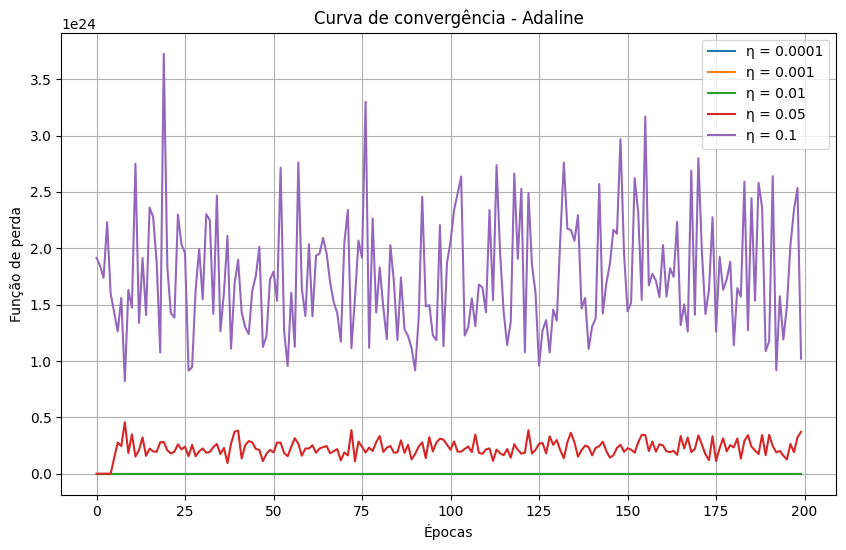

In [0]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

# Convertendo dados para Pandas.
df_pd = df_norm.toPandas()

# Separando X e Y.
X = df_pd.drop("classe", axis=1)
y = df_pd["classe"]

# Dividindo treino e teste (80/20).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Taxas de aprendizagem.
etas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]

plt.figure(figsize=(10,6))

# Treinamento e curvas de convergência.
for eta in etas:
    modelo = SGDRegressor(
        loss="squared_error",
        learning_rate="constant",
        eta0=eta,
        max_iter=1,
        tol=None,
        random_state=42
    )
    
    losses = []

    # Treinando as épocas.
    for epoch in range(200):
        modelo.partial_fit(X_train, y_train)
        
        y_pred = modelo.predict(X_train)
        
        # Função de perda do Adaline (MSE / 2).
        loss = ((y_train - y_pred) ** 2).mean() / 2
        losses.append(loss)

    # Plotagem da curva.
    plt.plot(losses, label=f"η = {eta}")

# Plotagem do grafico.
plt.xlabel("Épocas")
plt.ylabel("Função de perda")
plt.title("Curva de convergência - Adaline")
plt.legend()
plt.grid()

plt.show()

In [0]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Melhor taxa de aprendizagem.
eta_melhor = 1e-2

# Treinamento do modelo final.
modelo_final = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=eta_melhor,
    max_iter=200,
    tol=None,
    random_state=42
)

modelo_final.fit(X_train, y_train)

# Previsões.
y_pred_continuo = modelo_final.predict(X_test)

# Converter saída contínua → classe (+1 / -1).
y_pred = [1 if y >= 0 else -1 for y in y_pred_continuo]

# Métricas.
matriz = confusion_matrix(y_test, y_pred)
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

# Resultado.
print("Matriz de Confusão:")
print(matriz)

print("\nMétricas:")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Matriz de Confusão:
[[18  7]
 [ 2 44]]

Métricas:
Acurácia: 0.8732
Precisão: 0.8627
Recall: 0.9565
F1-score: 0.9072
